In [34]:
import napari
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftshift, ifft
from scipy.signal import windows
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
# Input widgets
input_directory_input = widgets.Text(
    value='C:/Users/mheldb/Documents/Image_analysis/2025-07-02-BURTON-Will-python-cardiac-frequency-analysis/input-data/',
    description='Directory:',
    style={'description_width': 'auto'},
    layout=widgets.Layout(width='400px')
)

input_file_input = widgets.Text(
    value='25-02-06_Exp11_F_A1_CTL_V-OME TIFF-Export-01_crop_200.ome.tif',
    description='File name:',
    style={'description_width': 'auto'},
    layout=widgets.Layout(width='400px')
)

video_rate_input = widgets.FloatText(
    value=34,
    description='Video rate (fps):',
    style={'description_width': 'auto'}
)

exp_beat_rate_input = widgets.FloatText(
    value=0.1,
    description='Beat rate (Hz):',
    style={'description_width': 'auto'}
)

offset_input = widgets.FloatText(
    value=15,
    description='Offset:',
    style={'description_width': 'auto'}
)

checkbox_offset_calculation_input = widgets.Checkbox(
    value=False,
    description='Calculate offset from video rate & beat rate',
    indent=False,
    style={'description_width': 'auto'}
)

pixel_calibration_input = widgets.FloatText(
    value=1.3798,
    description='Pixel Calibration (µm/px):',
    style={'description_width': 'auto'}
)

# Run button
run_button = widgets.Button(
    description='Run analysis',
    button_style='success',
    icon='check'
)

# Output area
output = widgets.Output()

# Define action on button click
def on_run_button_clicked(b):
    with output:
        clear_output()
        directory = input_directory_input.value
        filename = input_file_input.value
        video_rate = video_rate_input.value
        beat_rate = exp_beat_rate_input.value
        offset = offset_input.value
        auto_offset = checkbox_offset_calculation_input.value
        pixel_calibration = pixel_calibration_input.value
        
        offset = None
        if auto_offset:
            offset = int(0.2 * video_rate / beat_rate)
        else: 
            offset = int(offset_input.value)
        
        print(f"📁 Directory: {directory}")
        print(f"📄 File: {filename}")
        print(f"🎥 Video rate: {video_rate} fps")
        print(f"❤️ Beat rate: {beat_rate} Hz")
        print(f"⌚ Offset: {offset} ")
        print(f"🔁 Auto offset calc: {auto_offset}")
        if offset is not None:
            print(f"🧮 Calculated offset: {offset}")
        else:
            print(f"⚠️ Offset specified manually")
        print(f"📏 Pixel calibration: {pixel_calibration}")
run_button.on_click(on_run_button_clicked)

# Display form
form = widgets.VBox([
    input_directory_input,
    input_file_input,
    video_rate_input,
    exp_beat_rate_input,
    offset_input,
    checkbox_offset_calculation_input,
    pixel_calibration_input,
    run_button,
    output
])

display(form)

In [35]:
input_directory = Path(input_directory_input.value)
input_file = input_file_input.value
video_rate = video_rate_input.value
exp_beat_rate = exp_beat_rate_input.value
offset = int(offset_input.value)
auto_offset = checkbox_offset_calculation_input.value  # gets overridden next:
if auto_offset:
    offset = int(0.2 * video_rate / exp_beat_rate)  # calculated, not from widget
checkbox_offset_calculation = checkbox_offset_calculation_input.value
pixel_calibration = pixel_calibration_input.value

print(f"Running with: {input_directory}, {input_file}, {video_rate}, {exp_beat_rate}, {offset}, {checkbox_offset_calculation}")


Running with: C:\Users\mheldb\Documents\Image_analysis\2025-07-02-BURTON-Will-python-cardiac-frequency-analysis\input-data, 25-02-06_Exp11_F_A1_CTL_V-OME TIFF-Export-01_crop_200.ome.tif, 34.0, 0.1, 68, True


In [36]:
# File paths
#directory = Path("C:/Users/mheldb/Documents/Image_analysis/2025-07-02-BURTON-Will-python-cardiac-frequency-analysis/input-data/")
#input_filename = "25-02-06_Exp11_F_A1_CTL_V-OME TIFF-Export-01_crop_200.ome.tif"
input_path = input_directory / input_file
filename_without_extension = input_path.stem

# Load time series image
print("Importing image data")
TimeSeriesData = tifffile.imread(input_path)  # shape: (frames, height, width)
TimeSeriesData = TimeSeriesData.astype(np.uint16)
TimeSeriesData = np.transpose(TimeSeriesData, (1, 2, 0))  # to (H, W, T)
number_of_frames = TimeSeriesData.shape[2]
print(f"Number of frames: {number_of_frames}")

viewer = napari.Viewer()
viewer.add_image(np.transpose(TimeSeriesData, (2, 0, 1)), name="Original Stack", blending="additive")



Importing image data
Number of frames: 409


<Image layer 'Original Stack' at 0x1ec0fbbb290>

In [37]:
# ---- First: Pixel Variance over rolling window ----
print("Calculating Pixel Variance data")
PV_data_stack = np.zeros((TimeSeriesData.shape[0], TimeSeriesData.shape[1], number_of_frames - offset), dtype=np.float32)

for j in range(number_of_frames - offset):
    #PV_data_stack[:, :, j] = np.std(TimeSeriesData[:, :, j:j + offset], axis=2, ddof=1)
    PV_data_stack[:, :, j] = np.std(TimeSeriesData[:, :, j:j + offset + 1], axis=2, ddof=1)

# Normalize to 16-bit
print("Normalising Pixel Variance data")
pv_min = PV_data_stack.min()
pv_max = PV_data_stack.max()
PV_data_stack = ((PV_data_stack - pv_min) / (pv_max - pv_min) * 65535).astype(np.uint16)

# Save stack
output_tiff = input_directory / f"{filename_without_extension}_PixelVariance.tiff"
tifffile.imwrite(output_tiff, np.transpose(PV_data_stack, (2, 0, 1)), photometric='minisblack')

# ---- Second: Calculate 'speed' ----
print("Calculating Speed")
speed = [np.mean(PV_data_stack[:, :, j]) for j in range(PV_data_stack.shape[2])]
speed = np.array(speed)
speed_scaled = speed * pixel_calibration

# ---- Third: Find key_frame (min speed) ----
key_frame = np.argmin(speed)

# ---- Fourth: Calculate contraction ----
print("Calculating contraction data")
sample_window = offset
TimeSeriesData = TimeSeriesData.astype(np.float32)
contraction = []

for i in range(number_of_frames - sample_window):
    # Standard deviation over the sample window for each pixel
    current_std = np.std(TimeSeriesData[:, :, i:i + sample_window], axis=2)
    key_std = np.std(TimeSeriesData[:, :, key_frame:key_frame + sample_window], axis=2)

    # Absolute difference and mean over spatial dimensions
    diff = np.abs(current_std - key_std)
    contraction_value = np.mean(diff)

    contraction.append(contraction_value)
#contraction = np.array(contraction)
# Smooth using Hann window
#f_contraction = fftshift(fft(contraction))
#f_contraction *= windows.hann(len(contraction), sym=True)
#contraction_filtered = np.real(ifft(fftshift(f_contraction)))
#contraction_scaled = contraction_filtered * pixel_calibration

# contraction = your 1D NumPy array
N = len(contraction)
f_contraction = np.fft.fftshift(np.fft.fft(contraction))
filt = windows.hann(N, sym=False)  # Match MATLAB's hann
#filt = filt / np.sum(filt)  # if needed
f_contraction *= filt  # Apply symmetric Hann window
contraction_filtered = np.real(np.fft.ifft(np.fft.fftshift(f_contraction)))  # inverse with fftshift
contraction_scaled = contraction_filtered * pixel_calibration
print(contraction_scaled)

# ---- Time vectors and save data ----
time_series_c = np.arange(len(contraction)) / video_rate
output_c = np.vstack((time_series_c, contraction_filtered, contraction_scaled)).T

time_series_s = np.arange(len(speed)) / video_rate
output_s = np.vstack((time_series_s, speed, speed_scaled)).T

# Save data
np.savetxt(input_directory / f"{filename_without_extension}_contraction.txt", output_c, header="time contraction_scaled", fmt="%.4f %.8f %.8f")
np.savetxt(input_directory / f"{filename_without_extension}_speed.txt", output_s, header="time speed_scaled", fmt="%.4f %.8f %.8f")


Calculating Pixel Variance data
Normalising Pixel Variance data
Calculating Speed
Calculating contraction data
[ 40.96111315  42.89953816  42.77253782  42.42955493  41.64205864
  40.48046307  39.28654701  38.31081329  37.61768293  37.1473339
  36.81275067  36.52026935  36.20118525  35.8291264   35.39295222
  34.91120786  34.40272144  33.86930701  33.32316863  32.77216499
  32.22291303  31.69759071  31.25283495  30.99012357  30.99682999
  31.2762965   31.70657366  32.09530532  32.31106513  32.35004873
  32.28180841  32.17045152  32.06146064  31.97221966  31.89128502
  31.79712072  31.67441913  31.52547948  31.33968244  31.10054609
  30.82050861  30.51098306  30.17951909  29.81814516  29.37094673
  28.8105931   28.15242447  27.30509177  26.16626897  24.86633201
  23.63071849  22.57111741  21.69624283  20.96103808  20.30427466
  19.6672793   19.01143842  18.32665749  17.6181011   16.89438173
  16.16087355  15.4212555   14.68083541  13.94079822  13.20532376
  12.49596228  11.83760994  11.2

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\mheldb\\Documents\\Image_analysis\\2025-07-02-BURTON-Will-python-cardiac-frequency-analysis\\input-data\\25-02-06_Exp11_F_A1_CTL_V-OME TIFF-Export-01_crop_200.ome_contraction.txt'

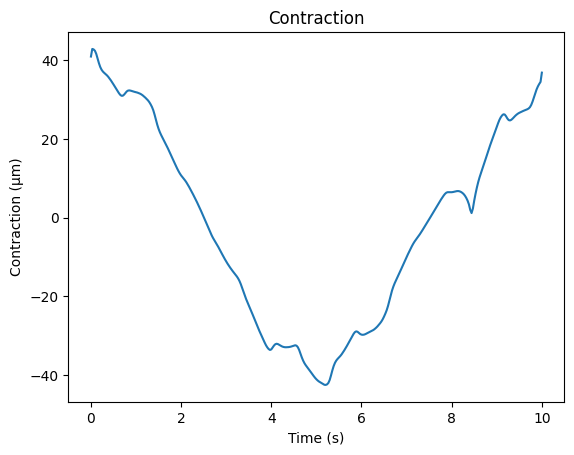

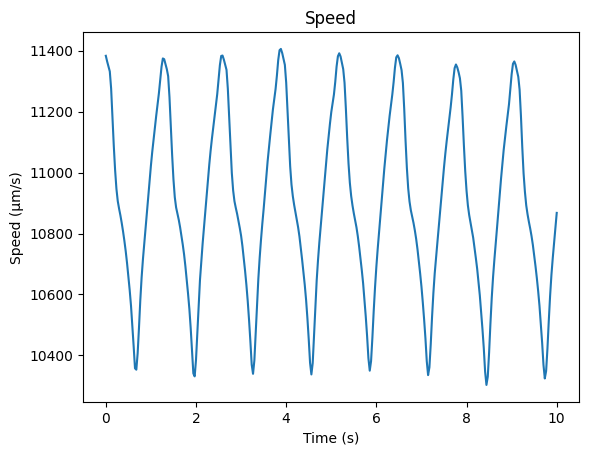

Done!


In [38]:
# ---- Plotting ----
plt.figure()
plt.plot(time_series_c, contraction_scaled)
plt.title('Contraction')
plt.xlabel('Time (s)')
plt.ylabel('Contraction (µm)')
plt.savefig(input_directory / f"{filename_without_extension}_contraction.png")
plt.show()

plt.figure()
plt.plot(time_series_s, speed_scaled)
plt.title('Speed')
plt.xlabel('Time (s)')
plt.ylabel('Speed (µm/s)')
plt.savefig(input_directory / f"{filename_without_extension}_speed.png")
plt.show()

print("Done!")


In [18]:

viewer.add_image(np.transpose(PV_data_stack, (2, 0, 1)), name="Pixel Variance Stack", blending="additive", colormap="magenta")


RuntimeError: wrapped C/C++ object of type QtViewer has been deleted